import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

read and see the data

In [3]:
df = pd.read_csv('./data/data.csv')
df.head()

,artist and title,wks,t10,pk,x?,PkStreams,total,artist name,song name,lyrics
0,The Weeknd - Blinding Lights,347,64.0,1,(x13),52375259,5441240333,The Weeknd,Blinding Lights,Yeah I've been tryna call I've been on my own ...
1,Ed Sheeran - Shape of You,424,34.0,1,(x14),64217796,4470842634,Ed Sheeran,Shape of You,The club isn't the best place to find a lover ...
2,Harry Styles - As It Was,218,60.0,1,(x11),78460903,4417264164,Harry Styles,As It Was,﻿ As It Was - Harry Styles Come on Harry we wa...
3,The Neighbourhood - Sweater Weather,333,NaN,16,NaN,21624450,4142643719,The Neighbourhood,Sweater Weather,And all I am is a man I want the world in my h...
4,Lewis Capaldi - Someone You Loved,343,15.0,4,NaN,24962682,3933581891,Lewis Capaldi,Someone You Loved,I'm going under and this time I fear there's n...


rename and clean

In [4]:
df = df.rename(columns={"x?": "weeks_at_peak"})
df["weeks_at_peak"] = df["weeks_at_peak"].fillna(1)
df = df.drop(columns=["artist and title"])

drop rows with no lyrics for the NLP part (keep a separate df for general stats)

In [5]:
df_lyrics = df.dropna(subset=["lyrics"])

sanity checks

In [6]:
df.describe()

,wks,t10,pk,PkStreams,total
count,8058.000000,810.000000,8058.000000,8.058000e+03,8.058000e+03
mean,15.510549,8.209877,83.664185,1.156726e+07,1.419280e+08
std,30.921408,8.984420,60.125907,1.025781e+07,3.394366e+08
min,1.000000,1.000000,1.000000,1.669100e+05,1.669100e+05
25%,1.000000,1.000000,30.000000,5.368128e+06,8.916825e+06
50%,4.000000,5.000000,74.000000,8.941470e+06,2.798093e+07
75%,17.000000,13.000000,132.000000,1.414555e+07,1.188043e+08
max,457.000000,71.000000,246.000000,1.288961e+08,5.441240e+09


In [7]:
df["pk"].value_counts().head(10)

pk
1     134
2     111
3      89
6      80
14     79
19     74
9      74
4      72
21     71
5      70
Name: count, dtype: int64

## Part 1: Does Chart Longevity Predict Total Streams?

**Question:** Do songs that stay on the chart longer accumulate proportionally more total streams?

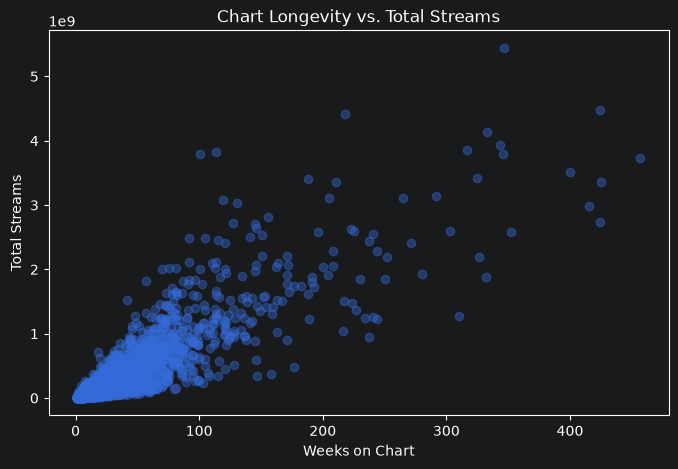

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df["wks"], df["total"], alpha=0.4)
plt.xlabel("Weeks on Chart")
plt.ylabel("Total Streams")
plt.title("Chart Longevity vs. Total Streams")
plt.savefig("./images/chart_longevity_vs_streams.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** There's a positive relationship, but it's not tight — the spread widens a lot at higher weeks-on-chart. This means duration alone doesn't fully explain streaming success; something else (likely peak position) plays a bigger role.

## Part 2: Does Peak Position Predict Total Streams?

**Question:** Does reaching a higher (better) peak chart position correlate with more total streams?

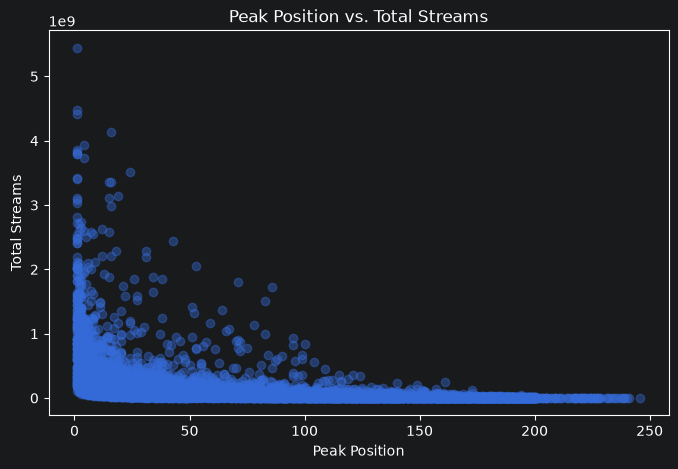

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["pk"], df["total"], alpha=0.4)
plt.xlabel("Peak Position")
plt.ylabel("Total Streams")
plt.title("Peak Position vs. Total Streams")
plt.savefig("./images/peak_position_vs_streams.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Yes — this relationship is much stronger and tighter than chart longevity. Songs peaking in the top 20 dominate total streams, while songs with a similar number of weeks charted but a worse peak show far lower totals. Peak position looks like the stronger predictor of the two.

## Part 3: Does Lyric Length Relate to Streaming Success?

**Question:** Does anything about the lyrics themselves — starting with simple length — relate to a song's streaming success?

In [10]:
df_lyrics["word_count"] = df_lyrics["lyrics"].apply(lambda x: len(str(x).split()))

Checking the distribution of word counts to spot anything unusual (e.g. suspiciously short or long lyrics that might indicate messy data).

In [11]:
df_lyrics["word_count"].describe()

count     8043.000000
mean       403.980231
std        231.877366
min          7.000000
25%        280.000000
50%        370.000000
75%        487.000000
max      12518.000000
Name: word_count, dtype: float64

In [12]:
df_lyrics[df_lyrics["word_count"] > 3000][["artist name", "song name", "word_count"]]

,artist name,song name,word_count
5637,Metro Boomin,I Can't Save You [with Future & feat. Don Tol...,12518


In [13]:
df_lyrics[df_lyrics["word_count"] < 20][["artist name", "song name", "word_count"]]

,artist name,song name,word_count
5376,Martin Garrix,Animals,8
6629,Metro Boomin,Dreamcatcher,19
6693,Kid Cudi,Beautiful Trip,7
6914,Martin Garrix,Animals,8
7445,Metro Boomin,Borrowed Love,8


In [14]:
df_lyrics = df_lyrics[df_lyrics["word_count"] < 3000]

In [15]:
df_lyrics["word_count"].describe()

count    8042.000000
mean      402.473887
std       188.471158
min         7.000000
25%       280.000000
50%       370.000000
75%       486.750000
max      2844.000000
Name: word_count, dtype: float64

First, I calculated word count per song and checked the distribution for data quality issues.

**Data cleaning note:** One row had a word count of 12,518 — far beyond any plausible song length.
Inspection showed the lyrics field contained leftover HTML artifacts (`NBSP` codes) from the scraping
process, corrupting the text. This row was removed. Several genuinely short lyric counts (7-19 words)
were also found, but inspection confirmed these were legitimate — mostly EDM/instrumental-heavy tracks
(e.g. Martin Garrix, Metro Boomin) with minimal lyrical content, not data errors. These were kept.

Now plotting word count against total streams to see if longer or shorter songs tend to perform better.

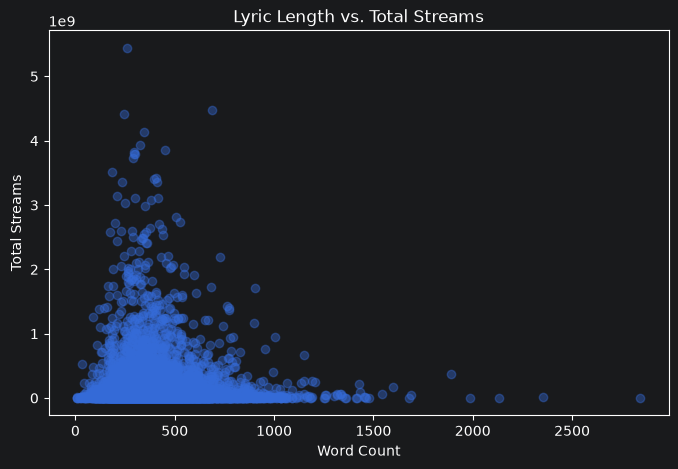

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df_lyrics["word_count"], df_lyrics["total"], alpha=0.4)
plt.xlabel("Word Count")
plt.ylabel("Total Streams")
plt.title("Lyric Length vs. Total Streams")
plt.savefig("./images/word_count_vs_streams.png", dpi=150, bbox_inches="tight")
plt.show()